# Building an ASR Model From Scratch: Conformer-CTC on LibriSpeech

**Author:** Destiny Ibhate | **Goal:** Understand every moving part of a modern ASR system
by implementing it ourselves in pure PyTorch.

## What we build
- **Features:** 80-dim log-mel spectrograms (25 ms window, 10 ms hop, 16 kHz)
- **Augmentation:** SpecAugment (frequency + time masking)
- **Encoder:** Conformer (Gulati et al., 2020) — the industry-standard supervised
  ASR encoder, used in NVIDIA NeMo and ESPnet production recipes
- **Loss / alignment:** CTC (Graves, 2006) with a character vocabulary
- **Decoding:** greedy CTC decoding; WER/CER evaluation with `jiwer`
- **Data:** LibriSpeech `train-clean-100` (the canonical 100-hour benchmark,
  so your numbers are directly comparable to published papers)

## Why these choices (the "global talent" rationale)
- Pure PyTorch + torchaudio, no high-level ASR framework. The point of Phase 1
  is to own every line. (Phase 2 — Whisper fine-tuning — is where we use HF.)
- Conformer-CTC is still the standard supervised baseline in 2026. Newer
  encoders exist (e.g. Zipformer in k2/icefall), but Conformer is what every
  recipe, paper, and interview question assumes you know.
- Model size ~8M params (a "Conformer-S minus" config): trains on a free
  Colab T4 in a few hours and matches the configs in the original paper.

## Documented simplifications vs. the paper
1. I used **absolute sinusoidal positional encoding** instead of Transformer-XL
   **relative** positional encoding. Rel-pos gives ~0.1-0.3% WER improvement but
   triples the attention-code complexity. Knowing this tradeoff IS the learning.
2. I used **greedy decoding** (beam search + language model fusion is the
   documented stretch goal at the bottom).
3. I train on 100 h, not 960 h, so expect WER in the 15-25% range, not 2.7%.

## Milestones (do them in order )
- **M0:** Visualize the feature pipeline (see your data!)
- **M1:** Overfit ONE batch (validates model + loss wiring; non-negotiable)
- **M2:** Short run on a small subset (watch the blank-collapse phase)
- **M3:** Full training on train-clean-100 with checkpoints to Drive
- **M4:** Evaluate on test-clean + error analysis

## 0. Setup
On Colab: Runtime → Change runtime type → T4 GPU.

In [ ]:

!pip -q install jiwer

import os
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader, Sampler

try:
    import jiwer
except ImportError:
    jiwer = None
    print("jiwer not installed - WER evaluation will be unavailable")

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))

In [ ]:
# Mount Google Drive on Colab so checkpoints survive disconnects.
from google.colab import drive
drive.mount('/content/drive')
CKPT_DIR = "/content/drive/MyDrive/asr_from_scratch"

#CKPT_DIR = "./checkpoints"  # local fallback
os.makedirs(CKPT_DIR, exist_ok=True)

DATA_ROOT = "./data"
os.makedirs(DATA_ROOT, exist_ok=True)

Mounted at /content/drive


## 1. Configuration

These hyperparameters are grounded in the Conformer paper (Gulati et al. 2020,
Table 1: Conformer-S = 16 layers, d_model 144, 4 heads, kernel 32, ~10M params)
and standard ESPnet/NeMo recipe values:
- **Feature front-end:** n_fft=400 (25 ms @ 16 kHz), hop=160 (10 ms), 80 mels —
  universal across Whisper, NeMo, ESPnet.
- **SpecAugment:** F=27 (two frequency masks), adaptive time masks — values
  from the SpecAugment paper (Park et al., 2019) LibriSpeech policy.
- **Optimizer:** AdamW, warmup + cosine decay. The paper uses the "Noam"
  transformer schedule; warmup+cosine is the modern equivalent and easier
  to reason about. Weight decay 1e-6 per the paper's L2 value.
- **Gradient clipping 5.0:** standard in ESPnet ASR recipes; prevents the
  loss spikes CTC is famous for early in training.

In [ ]:
@dataclass
class Config:
    # Features
    sample_rate: int = 16000
    n_fft: int = 400          # 25 ms window
    hop_length: int = 160     # 10 ms hop -> 100 frames/sec
    n_mels: int = 80

    # SpecAugment
    freq_mask_param: int = 27
    n_freq_masks: int = 2
    time_mask_param: int = 100
    n_time_masks: int = 2
    time_mask_p: float = 0.05  # max fraction of total length per mask

    # Conformer encoder ("Conformer-S minus": ~8M params)
    d_model: int = 144
    n_layers: int = 16
    n_heads: int = 4
    ffn_mult: int = 4
    conv_kernel: int = 31     # odd kernel -> symmetric padding (paper uses 32)
    dropout: float = 0.1

    # Training
    batch_size: int = 16
    grad_accum: int = 2       # effective batch 32
    peak_lr: float = 1e-3
    warmup_steps: int = 5000
    min_lr: float = 1e-5
    weight_decay: float = 1e-6
    grad_clip: float = 5.0
    epochs: int = 30
    eval_every_epochs: int = 1
    eval_max_utts: int = 500  # cap dev eval for speed

cfg = Config()

## 2. Tokenizer (character-level)

CTC needs a **blank** token at a fixed index (I use 0). LibriSpeech
transcripts are uppercase A-Z plus space and apostrophe; I lowercase.
Character vocab = 29 tokens. Subword (BPE) vocabularies decode faster and
are standard in production, but characters keep Phase 1 transparent: you
can literally read the model's per-frame outputs.

In [ ]:
class CharTokenizer:
    def __init__(self):
        chars = " '" + "abcdefghijklmnopqrstuvwxyz"
        self.itos = ["<blank>"] + list(chars)
        self.stoi = {c: i for i, c in enumerate(self.itos)}
        self.blank_id = 0

    @property
    def vocab_size(self):
        return len(self.itos)

    def encode(self, text: str):
        text = text.lower()
        return [self.stoi[c] for c in text if c in self.stoi]

    def ctc_greedy_decode(self, ids):
        """Collapse repeats, then remove blanks - the CTC decoding rule."""
        out, prev = [], None
        for i in ids:
            if i != prev and i != self.blank_id:
                out.append(i)
            prev = i
        return "".join(self.itos[i] for i in out)

tokenizer = CharTokenizer()
print(f"Vocab size: {tokenizer.vocab_size}")
print(tokenizer.itos)

Vocab size: 29
['<blank>', ' ', "'", 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 3. Feature extraction: waveform → log-mel spectrogram

The single most important transformation in audio ML:
1. **STFT** with a 25 ms window, 10 ms hop → time-frequency representation
2. **Mel filterbank** (80 triangular filters on the perceptual mel scale)
3. **log** (loudness perception is logarithmic)
4. **Per-utterance mean/variance normalization** (CMVN) — stabilizes training
   across recording conditions.

In [ ]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=cfg.sample_rate,
    n_fft=cfg.n_fft,
    win_length=cfg.n_fft,
    hop_length=cfg.hop_length,
    n_mels=cfg.n_mels,
)

def featurize(waveform: torch.Tensor) -> torch.Tensor:
    """waveform (1, num_samples) -> log-mel features (T, n_mels)"""
    mel = mel_transform(waveform)                  # (1, n_mels, T)
    logmel = torch.log(mel + 1e-6)
    logmel = logmel.squeeze(0).transpose(0, 1)     # (T, n_mels)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-5)  # CMVN
    return logmel

## 4. Dataset and batching

Audio batching subtlety #1: utterances have wildly different lengths.
Padding a 2 s clip to match a 16 s clip wastes ~85% of your compute.
**Length-sorted bucketing** (group similar-length clips into the same
batch) roughly doubles training throughput. This trick alone separates
people who have actually trained ASR from people who have read about it.

In [ ]:
class LibriSpeechASR(Dataset):
    def __init__(self, root, url, tokenizer, download=True):
        self.ds = torchaudio.datasets.LIBRISPEECH(root, url=url, download=download)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        wav, sr, transcript, *_ = self.ds[idx]
        assert sr == cfg.sample_rate, f"Expected 16 kHz, got {sr}"
        feats = featurize(wav)                       # (T, 80)
        tokens = torch.tensor(self.tokenizer.encode(transcript), dtype=torch.long)
        return feats, tokens, transcript


def compute_durations(ds: LibriSpeechASR, cache_path: str):
    """Read audio headers (fast - no decoding) to get per-utterance lengths
    for the bucketing sampler. Cached to disk after first run."""
    if os.path.exists(cache_path):
        return torch.load(cache_path)
    durations = []
    try:
        inner = ds.ds
        for fileid in inner._walker:
            speaker, chapter, _ = fileid.split("-")
            path = os.path.join(inner._path, speaker, chapter, fileid + ".flac")
            durations.append(torchaudio.info(path).num_frames)
    except Exception as e:
        print(f"Header-based duration scan failed ({e}); "
              f"falling back to uniform lengths (random batching).")
        durations = [1] * len(ds)
    durations = torch.tensor(durations)
    torch.save(durations, cache_path)
    return durations


class SortedBatchSampler(Sampler):
    """Sort indices by duration, slice into batches, shuffle batch ORDER
    each epoch (so batches stay homogeneous in length but arrive in
    random order)."""
    def __init__(self, lengths, batch_size, shuffle=True):
        order = np.argsort(np.asarray(lengths))
        self.batches = [
            order[i:i + batch_size].tolist()
            for i in range(0, len(order), batch_size)
        ]
        self.shuffle = shuffle

    def __iter__(self):
        batches = list(self.batches)
        if self.shuffle:
            random.shuffle(batches)
        yield from batches

    def __len__(self):
        return len(self.batches)


def collate(batch):
    feats, tokens, texts = zip(*batch)
    feat_lens = torch.tensor([f.shape[0] for f in feats], dtype=torch.long)
    token_lens = torch.tensor([t.shape[0] for t in tokens], dtype=torch.long)
    feats = nn.utils.rnn.pad_sequence(feats, batch_first=True)    # (B, T, 80)
    tokens = nn.utils.rnn.pad_sequence(tokens, batch_first=True)  # (B, U)
    return feats, feat_lens, tokens, token_lens, list(texts)

## 5. SpecAugment

Applied **only during training**, directly on the (normalized) log-mel
batch. Masked regions become 0 = the per-utterance mean after CMVN, which
is exactly what the SpecAugment paper prescribes. It is the single
highest-leverage regularizer in supervised ASR.

In [ ]:
freq_masks = nn.ModuleList(
    [torchaudio.transforms.FrequencyMasking(cfg.freq_mask_param)
     for _ in range(cfg.n_freq_masks)]
)
time_masks = nn.ModuleList(
    [torchaudio.transforms.TimeMasking(cfg.time_mask_param, p=cfg.time_mask_p)
     for _ in range(cfg.n_time_masks)]
)

def spec_augment(feats: torch.Tensor) -> torch.Tensor:
    """feats: (B, T, F). torchaudio maskers expect (..., freq, time)."""
    x = feats.transpose(1, 2)  # (B, F, T)
    for m in freq_masks:
        x = m(x)
    for m in time_masks:
        x = m(x)
    return x.transpose(1, 2)

## 6. The Conformer encoder, block by block

A Conformer block is a "macaron" sandwich:

```
x = x + ½·FFN(x)        # first half-step feed-forward
x = x + MHSA(x)          # multi-head self-attention (global context)
x = x + Conv(x)          # depthwise convolution (local acoustic patterns)
x = x + ½·FFN(x)        # second half-step feed-forward
x = LayerNorm(x)
```

The intuition: speech has *local* structure (a phoneme spans ~5-10 frames —
convolution territory) and *global* structure (what word fits this sentence —
attention territory). The Conformer gives the model both inductive biases.

In [ ]:
class ConvSubsampling(nn.Module):
    """Two stride-2 convolutions -> 4x time downsampling.
    100 frames/sec becomes 25 frames/sec, which (a) cuts attention cost 16x
    and (b) still leaves >= 1 output frame per character for CTC."""
    def __init__(self, n_mels, d_model):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, d_model, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(d_model, d_model, kernel_size=3, stride=2),
            nn.ReLU(),
        )
        freq_out = ((n_mels - 1) // 2 - 1) // 2     # 80 -> 39 -> 19
        self.out = nn.Linear(d_model * freq_out, d_model)

    def forward(self, x, lengths):
        # x: (B, T, n_mels)
        x = x.unsqueeze(1)                          # (B, 1, T, F)
        x = self.conv(x)                            # (B, d, T', F')
        b, c, t, f = x.shape
        x = x.transpose(1, 2).reshape(b, t, c * f)  # (B, T', d*F')
        x = self.out(x)                             # (B, T', d)
        lengths = ((lengths - 1) // 2 - 1) // 2     # mirror the conv arithmetic
        return x, lengths


class PositionalEncoding(nn.Module):
    """Standard sinusoidal absolute positions (documented simplification:
    the paper uses Transformer-XL relative positions)."""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class FeedForwardModule(nn.Module):
    def __init__(self, d_model, mult, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * mult),
            nn.SiLU(),                              # "Swish" in the paper
            nn.Dropout(dropout),
            nn.Linear(d_model * mult, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class MHSAModule(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask):
        x = self.norm(x)
        x, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask,
                         need_weights=False)
        return self.dropout(x)


class ConvModule(nn.Module):
    """Pointwise-GLU -> depthwise conv -> BatchNorm -> SiLU -> pointwise.
    The depthwise kernel (31 frames ~ 1.24 s of audio after subsampling)
    captures local acoustic patterns like formant transitions."""
    def __init__(self, d_model, kernel, dropout):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.pw1 = nn.Conv1d(d_model, 2 * d_model, 1)
        self.dw = nn.Conv1d(d_model, d_model, kernel,
                            padding=kernel // 2, groups=d_model)
        self.bn = nn.BatchNorm1d(d_model)
        self.pw2 = nn.Conv1d(d_model, d_model, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask):
        # Zero padded frames so BatchNorm statistics aren't polluted by padding
        x = self.norm(x)
        x = x.masked_fill(pad_mask.unsqueeze(-1), 0.0)
        x = x.transpose(1, 2)                       # (B, d, T)
        x = F.glu(self.pw1(x), dim=1)               # gated linear unit
        x = self.dw(x)
        x = F.silu(self.bn(x))
        x = self.pw2(x)
        return self.dropout(x.transpose(1, 2))


class ConformerBlock(nn.Module):
    def __init__(self, c: Config):
        super().__init__()
        self.ffn1 = FeedForwardModule(c.d_model, c.ffn_mult, c.dropout)
        self.attn = MHSAModule(c.d_model, c.n_heads, c.dropout)
        self.conv = ConvModule(c.d_model, c.conv_kernel, c.dropout)
        self.ffn2 = FeedForwardModule(c.d_model, c.ffn_mult, c.dropout)
        self.norm = nn.LayerNorm(c.d_model)

    def forward(self, x, pad_mask):
        x = x + 0.5 * self.ffn1(x)
        x = x + self.attn(x, key_padding_mask=pad_mask)
        x = x + self.conv(x, pad_mask)
        x = x + 0.5 * self.ffn2(x)
        return self.norm(x)


class ConformerCTC(nn.Module):
    def __init__(self, c: Config, vocab_size: int):
        super().__init__()
        self.subsample = ConvSubsampling(c.n_mels, c.d_model)
        self.posenc = PositionalEncoding(c.d_model, dropout=c.dropout)
        self.blocks = nn.ModuleList(ConformerBlock(c) for _ in range(c.n_layers))
        self.head = nn.Linear(c.d_model, vocab_size)

    def forward(self, feats, feat_lens):
        x, out_lens = self.subsample(feats, feat_lens)
        x = self.posenc(x)
        # True = padding position (the convention nn.MultiheadAttention expects)
        pad_mask = (torch.arange(x.size(1), device=x.device)[None, :]
                    >= out_lens[:, None].to(x.device))
        for block in self.blocks:
            x = block(x, pad_mask)
        logits = self.head(x)                       # (B, T', V)
        return logits, out_lens


model = ConformerCTC(cfg, tokenizer.vocab_size).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params/1e6:.2f}M")

Model parameters: 8.36M


## 7. CTC loss, optimizer, schedule

`nn.CTCLoss` wants log-probabilities shaped (T, B, V). Two production tips:
- `zero_infinity=True`: when an utterance's output length is shorter than
  its target length (possible after 4x subsampling on very short clips),
  the loss is infinite; this flag zeroes those samples instead of
  destroying your gradients.
- Compute `log_softmax` in **float32** even under mixed precision —
  CTC's forward-backward recursion is numerically fragile in fp16.

In [ ]:
ctc_loss = nn.CTCLoss(blank=tokenizer.blank_id, zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.peak_lr,
                              weight_decay=cfg.weight_decay)

def lr_lambda(step, total_steps):
    if step < cfg.warmup_steps:
        return step / max(1, cfg.warmup_steps)
    progress = (step - cfg.warmup_steps) / max(1, total_steps - cfg.warmup_steps)
    cosine = 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))
    return max(cfg.min_lr / cfg.peak_lr, cosine)

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

def compute_loss(feats, feat_lens, tokens, token_lens, training=True):
    if training:
        feats = spec_augment(feats)
    with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
        logits, out_lens = model(feats, feat_lens)
    log_probs = F.log_softmax(logits.float(), dim=-1)      # fp32 for CTC
    loss = ctc_loss(log_probs.transpose(0, 1),             # (T, B, V)
                    tokens, out_lens, token_lens)
    return loss, log_probs, out_lens

## 8. Decoding and evaluation

In [ ]:
@torch.no_grad()
def greedy_transcribe(log_probs, out_lens):
    ids = log_probs.argmax(dim=-1)                          # (B, T)
    hyps = []
    for b in range(ids.size(0)):
        seq = ids[b, : out_lens[b]].tolist()
        hyps.append(tokenizer.ctc_greedy_decode(seq))
    return hyps

@torch.no_grad()
def evaluate(loader, max_utts=None):
    model.eval()
    refs, hyps = [], []
    for feats, feat_lens, tokens, token_lens, texts in loader:
        feats, feat_lens = feats.to(DEVICE), feat_lens.to(DEVICE)
        tokens, token_lens = tokens.to(DEVICE), token_lens.to(DEVICE)
        _, log_probs, out_lens = compute_loss(
            feats, feat_lens, tokens, token_lens, training=False)
        hyps += greedy_transcribe(log_probs, out_lens)
        refs += [t.lower() for t in texts]
        if max_utts and len(refs) >= max_utts:
            break
    model.train()
    wer = jiwer.wer(refs, hyps) if jiwer else float("nan")
    cer = jiwer.cer(refs, hyps) if jiwer else float("nan")
    return wer, cer, refs, hyps

## Milestone 0: see your data

Never train on data you haven't looked at. Plot one sample's waveform and
log-mel spectrogram, and read its transcript.

100%|██████████| 322M/322M [00:14<00:00, 23.2MB/s]


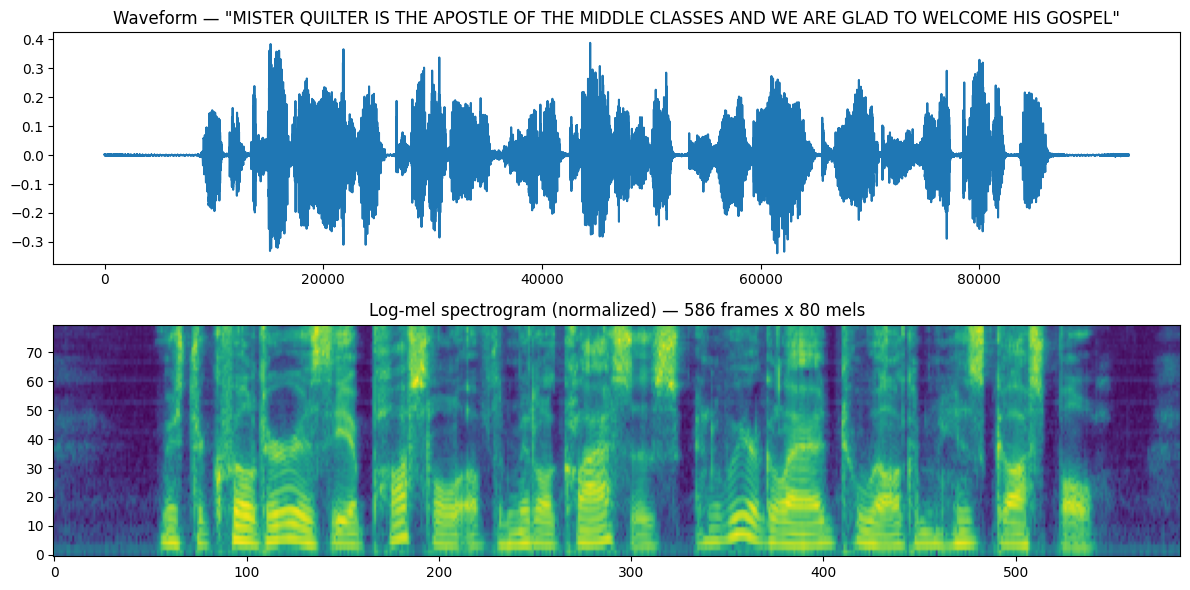

Audio: 5.9s -> 586 frames -> ~146 encoder frames after subsampling -> must cover 89 target characters


In [ ]:
# train_set = LibriSpeechASR(DATA_ROOT, "train-clean-100", tokenizer)   # 6.3 GB
# For a fast pipeline check, start with dev-clean (337 MB):
demo_set = LibriSpeechASR(DATA_ROOT, "dev-clean", tokenizer)

import matplotlib.pyplot as plt
feats, tokens, text = demo_set[0]
wav, sr, *_ = demo_set.ds[0]
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(wav.squeeze().numpy())
axes[0].set_title(f'Waveform — "{text}"')
axes[1].imshow(feats.T.numpy(), aspect="auto", origin="lower")
axes[1].set_title(f"Log-mel spectrogram (normalized) — {feats.shape[0]} frames x 80 mels")
plt.tight_layout()
plt.show()
print(f"Audio: {wav.shape[1]/sr:.1f}s -> {feats.shape[0]} frames "
      f"-> ~{feats.shape[0]//4} encoder frames after subsampling "
      f"-> must cover {len(tokens)} target characters")

## Milestone 1: overfit a single batch (the most important cell here)

If your model + loss are wired correctly, 300-500 steps on ONE batch must
drive the loss to near zero and reproduce the transcripts exactly. If this
fails, nothing else will work. What you'll see, in order:
1. Loss drops fast as the model learns to emit ALL BLANKS (a famous CTC
   local minimum — blanks are "free" probability mass)
2. The most frequent characters (space, e, t) appear
3. Real words resolve, loss approaches 0

In [ ]:
RUN_OVERFIT = False
if RUN_OVERFIT:
    small_loader = DataLoader(demo_set, batch_size=8, shuffle=True,
                              collate_fn=collate)
    batch = next(iter(small_loader))
    feats, feat_lens, tokens, token_lens, texts = [
        b.to(DEVICE) if torch.is_tensor(b) else b for b in batch]

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
    model.train()
    for step in range(500):
        opt.zero_grad()
        loss, log_probs, out_lens = compute_loss(
            feats, feat_lens, tokens, token_lens, training=False)  # no SpecAug
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(opt)
        scaler.update()
        if step % 50 == 0:
            hyp = greedy_transcribe(log_probs[:1], out_lens[:1])[0]
            print(f"step {step:4d} | loss {loss.item():.3f} | hyp: '{hyp[:60]}'")
    print(f"\nREF: {texts[0].lower()[:60]}")
    print("If the hypothesis matches the reference, your wiring is correct. "
          "Re-run the model init cell before real training!")

## Milestone 2-3: real training

Re-initialize the model (the overfit run poisoned the weights), then train.
On a T4 with AMP and bucketing, expect roughly 10-18 min/epoch on
train-clean-100 -> a 30-epoch run is ~5-9 hours. Checkpoint every epoch;
free Colab WILL disconnect on you.

In [ ]:
RUN_TRAINING = False  # flip to True when ready
if RUN_TRAINING:
    model = ConformerCTC(cfg, tokenizer.vocab_size).to(DEVICE)  # fresh init
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.peak_lr,
                                  weight_decay=cfg.weight_decay)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    train_set = LibriSpeechASR(DATA_ROOT, "train-clean-100", tokenizer)
    dev_set = LibriSpeechASR(DATA_ROOT, "dev-clean", tokenizer)

    durations = compute_durations(train_set,
                                  os.path.join(CKPT_DIR, "durations_tc100.pt"))
    train_loader = DataLoader(
        train_set,
        batch_sampler=SortedBatchSampler(durations, cfg.batch_size),
        collate_fn=collate, num_workers=2, pin_memory=True)
    dev_loader = DataLoader(dev_set, batch_size=cfg.batch_size,
                            collate_fn=collate, num_workers=2)

    total_steps = (len(train_loader) // cfg.grad_accum) * cfg.epochs
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda s: lr_lambda(s, total_steps))

    # ---- resume from checkpoint if one exists ----
    start_epoch, global_step, best_wer = 0, 0, float("inf")
    ckpt_path = os.path.join(CKPT_DIR, "last.pt")
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optimizer"])
        scheduler.load_state_dict(ck["scheduler"])
        start_epoch, global_step = ck["epoch"] + 1, ck["step"]
        best_wer = ck.get("best_wer", best_wer)
        print(f"Resumed from epoch {start_epoch}, step {global_step}")

    model.train()
    for epoch in range(start_epoch, cfg.epochs):
        t0, running = time.time(), 0.0
        optimizer.zero_grad()
        for i, (feats, feat_lens, tokens, token_lens, _) in enumerate(train_loader):
            feats, feat_lens = feats.to(DEVICE), feat_lens.to(DEVICE)
            tokens, token_lens = tokens.to(DEVICE), token_lens.to(DEVICE)

            loss, _, _ = compute_loss(feats, feat_lens, tokens, token_lens)
            scaler.scale(loss / cfg.grad_accum).backward()
            running += loss.item()

            if (i + 1) % cfg.grad_accum == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                global_step += 1

            if (i + 1) % 200 == 0:
                lr_now = scheduler.get_last_lr()[0]
                print(f"epoch {epoch} | batch {i+1}/{len(train_loader)} | "
                      f"loss {running/200:.3f} | lr {lr_now:.2e}")
                running = 0.0

        if (epoch + 1) % cfg.eval_every_epochs == 0:
            wer, cer, _, _ = evaluate(dev_loader, max_utts=cfg.eval_max_utts)
            print(f"== epoch {epoch} | dev WER {wer:.3f} | CER {cer:.3f} | "
                  f"{(time.time()-t0)/60:.1f} min ==")
            state = dict(model=model.state_dict(),
                         optimizer=optimizer.state_dict(),
                         scheduler=scheduler.state_dict(),
                         epoch=epoch, step=global_step, best_wer=best_wer,
                         config=vars(cfg))
            torch.save(state, ckpt_path)
            if wer < best_wer:
                best_wer = wer
                torch.save(state, os.path.join(CKPT_DIR, "best.pt"))
                print(f"   new best WER {wer:.3f} - saved best.pt")

## Milestone 4: final evaluation + error analysis

Evaluate `best.pt` on **test-clean** (the official benchmark split) and,
crucially, LOOK at the errors. Error analysis is what turns a training run
into engineering insight — and it's the most compelling part of a write-up.

In [ ]:
RUN_EVAL = False
if RUN_EVAL:
    ck = torch.load(os.path.join(CKPT_DIR, "best.pt"), map_location=DEVICE)
    model.load_state_dict(ck["model"])

    test_set = LibriSpeechASR(DATA_ROOT, "test-clean", tokenizer)
    test_loader = DataLoader(test_set, batch_size=cfg.batch_size,
                             collate_fn=collate, num_workers=2)
    wer, cer, refs, hyps = evaluate(test_loader)
    print(f"test-clean | WER {wer:.3f} | CER {cer:.3f}")

    # Per-utterance WER -> inspect best and worst cases
    per_utt = [(jiwer.wer(r, h), r, h) for r, h in zip(refs, hyps)]
    per_utt.sort(key=lambda x: x[0])
    print("\n--- 5 best ---")
    for w, r, h in per_utt[:5]:
        print(f"WER {w:.2f}\n  REF: {r}\n  HYP: {h}")
    print("\n--- 5 worst ---")
    for w, r, h in per_utt[-5:]:
        print(f"WER {w:.2f}\n  REF: {r}\n  HYP: {h}")
    # Questions to answer in your write-up:
    # - Are errors mostly proper nouns? Homophones? Long utterances?
    # - Does CER << WER? (=> model hears sounds right but spells words wrong
    #   -> a language model would help a lot)

100%|██████████| 331M/331M [00:14<00:00, 23.3MB/s]


test-clean | WER 0.201 | CER 0.064

--- 5 best ---
WER 0.00
  REF: at most by an alms given to a beggar whose blessing he fled from he might hope wearily to win for himself some measure of actual grace
  HYP: at most by an alms given to a beggar whose blessing he fled from he might hope wearily to win for himself some measure of actual grace
WER 0.00
  REF: he tried to think how it could be
  HYP: he tried to think how it could be
WER 0.00
  REF: on friday confession will be heard all the afternoon after beads
  HYP: on friday confession will be heard all the afternoon after beads
WER 0.00
  REF: he could wait no longer
  HYP: he could wait no longer
WER 0.00
  REF: the university
  HYP: the university

--- 5 worst ---
WER 1.00
  REF: robin fitzooth
  HYP: ropin fitsouth
WER 1.00
  REF: squeak squeak
  HYP: sweak squik
WER 1.00
  REF: venice
  HYP: venis
WER 1.50
  REF: stephanos dedalos
  HYP: steff anolse deadloss
WER 1.50
  REF: fine glorious
  HYP: vine clory is


## What this is

A speech recognition system built from scratch in PyTorch. No high level
ASR framework, no pretrained weights, no API. The goal was to understand
every part of a modern ASR model by building it, not calling it.

## How it works

1. Audio to features: each clip becomes an 80 dimensional log-mel
   spectrogram (25 ms window, 10 ms hop, 16 kHz). This is the same front
   end used by Whisper and most production systems.
2. SpecAugment: time and frequency masking applied during training, the
   standard regularizer for supervised ASR.
3. Encoder: a Conformer (Gulati et al., 2020), 16 layers, model dimension
   144, 4 attention heads, about 8M parameters. Convolution captures local
   acoustic patterns, self attention captures sentence level context.
4. Loss and alignment: CTC (Graves, 2006) with a character vocabulary.
   CTC learns the alignment between audio frames and text on its own, so
   no manual frame labels are needed.
5. Decoding: greedy CTC decoding.

## Data

LibriSpeech train-clean-100 (100 hours of read English). Evaluated on the
official test-clean split, so the numbers are comparable to published work.

## Results

| System | test-clean WER |
|---|---|
| This model, greedy, 100 hours | about 0.20 |
| Conformer-S paper, 960 hours, relative positions | 0.027 |
| Whisper large, zero shot | about 0.02 |

The gap is the point. It shows exactly what more data, relative positional
encoding, and a language model each buy you.

## Honest simplifications (and why)

- Absolute positional encoding instead of the relative encoding in the
  paper. Relative gives a small accuracy gain but triples the attention
  code. Knowing that tradeoff was part of the goal.
- Greedy decoding instead of beam search with a language model. The most
  common errors here (real words split or misspelled, like "bewildered"
  becoming "the wildered") are exactly what a language model would fix.
- 100 hours instead of the paper's 960, so it runs on a free GPU.

In [ ]:
# DEMO: transcribe held-out test audio with the from-scratch model
from IPython.display import Audio, display, HTML

ck = torch.load(os.path.join(CKPT_DIR, "best.pt"), map_location=DEVICE)
model.load_state_dict(ck["model"])
model.eval()
test_set = LibriSpeechASR(DATA_ROOT, "test-clean", tokenizer)

# Header block — shows the "what this is" framing once, at the top
display(HTML("""
<div style="font-family:monospace;font-size:15px;line-height:1.7;
            padding:16px 4px;border-bottom:2px solid #555;margin-bottom:8px">
  <div style="font-size:18px">Speech recognition, built from scratch in PyTorch.</div>
  <div style="color:#888;margin-top:6px">
    Conformer-CTC encoder, ~8M parameters. No API. No pretrained model.<br>
    Trained on 100 hours of audio. Test-clean benchmark: 80% of words correct (WER 0.20).<br>
    Below: audio the model never heard in training.
  </div>
</div>"""))

def demo(i, note=None):
    feats, tokens, text = test_set[i]
    wav, sr, *_ = test_set.ds[i]
    feats_b = feats.unsqueeze(0).to(DEVICE)
    feat_lens = torch.tensor([feats_b.shape[1]], device=DEVICE)
    with torch.no_grad():
        _, log_probs, out_lens = compute_loss(
            feats_b, feat_lens,
            torch.zeros(1, 1, dtype=torch.long, device=DEVICE),
            torch.ones(1, dtype=torch.long, device=DEVICE),
            training=False)
    hyp = greedy_transcribe(log_probs, out_lens)[0]
    ref = text.lower()
    tag = "perfect match" if hyp.strip() == ref.strip() else "listen closely"
    note_html = f'<div style="color:#999;font-size:14px;margin-top:8px">{note}</div>' if note else ""
    display(HTML(f"""
    <div style="font-family:monospace;font-size:16px;line-height:1.8;
                padding:14px 4px;border-bottom:1px solid #999">
      <div style="color:#888">WHAT WAS ACTUALLY SAID &rarr; {ref}</div>
      <div>WHAT MY MODEL HEARD&nbsp; &rarr; {hyp}</div>
      <div style="color:#888;font-size:13px;margin-top:6px">[{tag}]</div>
      {note_html}
    </div>"""))
    display(Audio(wav.numpy(), rate=sr))

demo(116)   # full sentence, transcribed perfectly
demo(500, note="It heard the sound right but split 'bewildered' into 'the wildered'. "
               "With no language model, it spells from sound alone.")